In [1]:
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18
})

In [2]:
file_path = 'Errors_BBH_ET_pop3_fid_10yr.txt'

data = np.loadtxt(file_path,comments='#').T

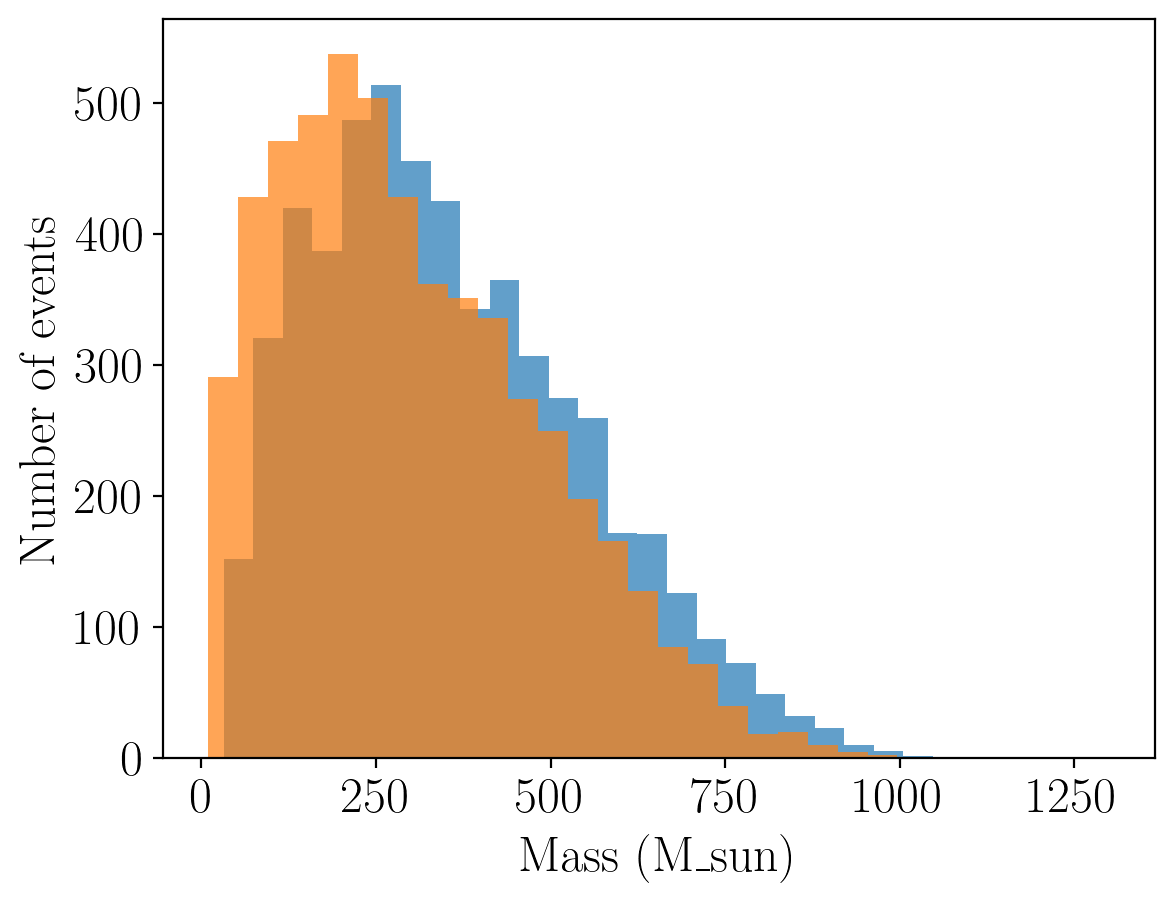

In [3]:
plt.hist(data[1], bins=30, alpha=0.7);
plt.hist(data[2], bins=30, alpha=0.7);
plt.xlabel('Mass (M_sun)');
plt.ylabel('Number of events');

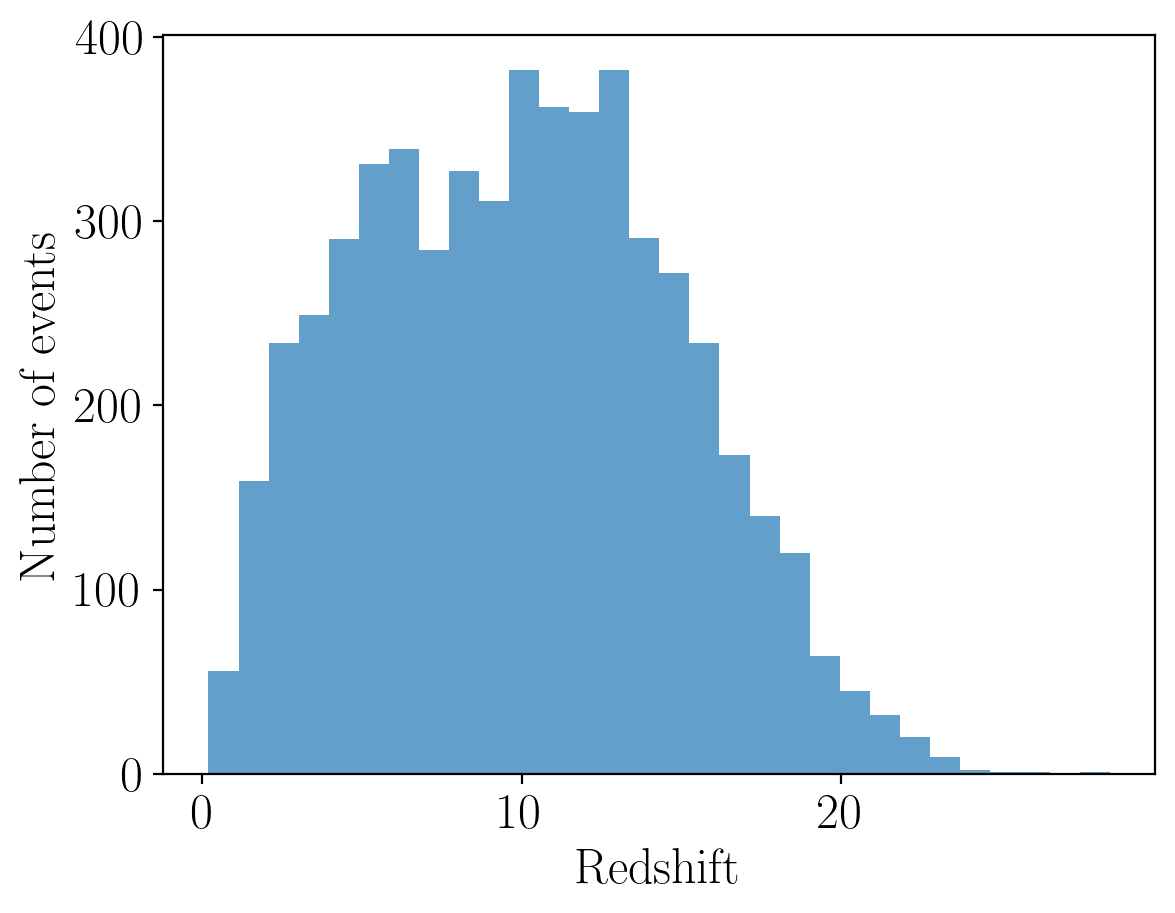

In [4]:
plt.hist(data[10], bins=30, alpha=0.7);
plt.xlabel('Redshift');
plt.ylabel('Number of events');

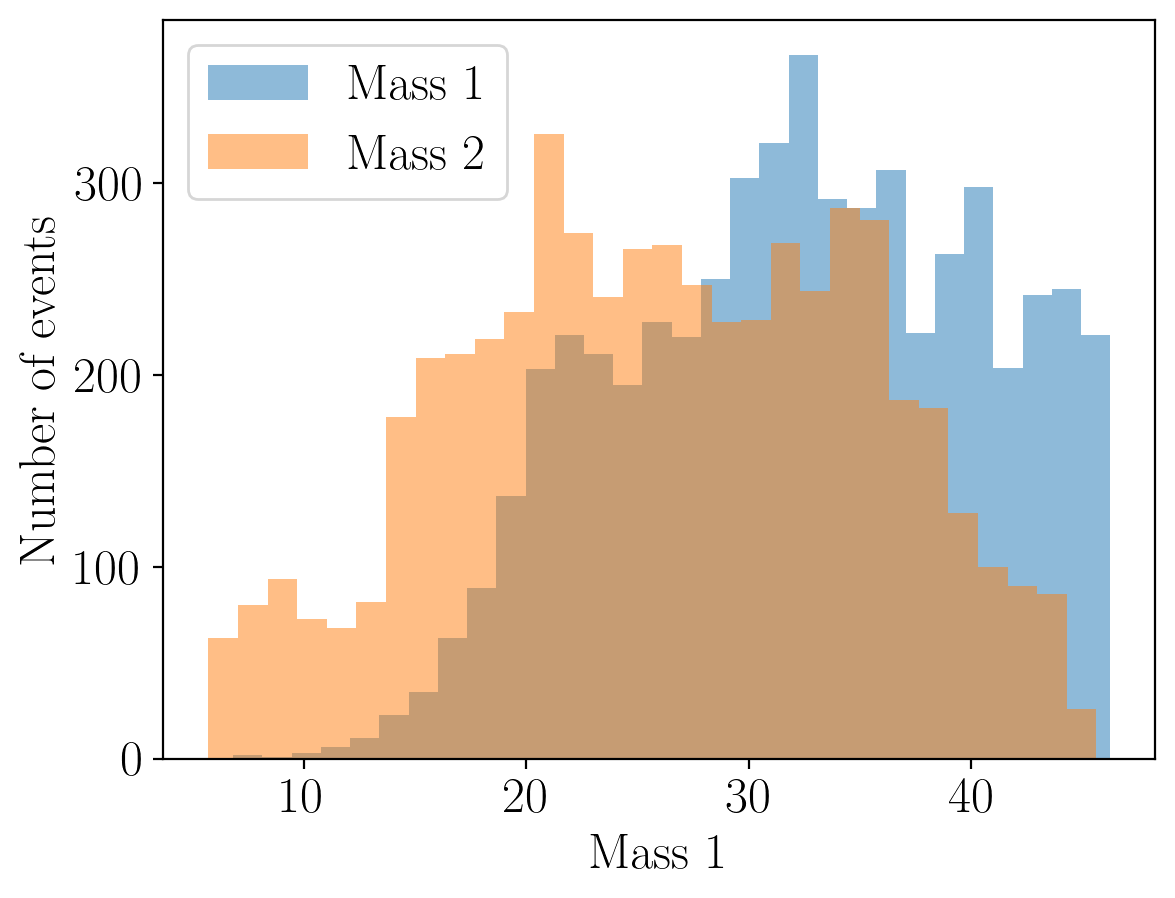

In [5]:
plt.hist(data[1]/(1+data[10]), bins=30, alpha=0.5, label='Mass 1')
plt.hist(data[2]/(1+data[10]), bins=30, alpha=0.5, label='Mass 2')
plt.xlabel('Mass 1')
plt.ylabel('Number of events')
plt.legend()

## Converting into GWFast catalog

In [6]:
pop_dict = {}

Nevents = len(data[1])

pop_dict['m1_src'] = data[1]/(1+data[10])
pop_dict['m2_src'] = data[2]/(1+data[10])
pop_dict['z'] = data[10]
pop_dict['dL'] = data[3]
pop_dict['dec'] = data[4]
pop_dict['ra'] = data[5]
pop_dict['thetaJN'] = data[6]
pop_dict['psi'] = data[7]

pop_dict['phi'] = pop_dict['ra']
pop_dict['theta'] = np.pi/2 - pop_dict['dec']

seed = 42

# Sampling spin magnitudes 
rng1 = np.random.default_rng(seed)
rng2 = np.random.default_rng(seed+1)

pop_dict['chi1z'] = rng1.beta(a=1, b=100, size=Nevents) * rng1.choice([-1, 1], size=Nevents)
pop_dict['chi2z'] = rng2.beta(a=1, b=100, size=Nevents) * rng2.choice([-1, 1], size=Nevents)

# Sampling coalescence phase and time uniformly
rng_phicoal = np.random.default_rng(seed+6)
rng_tcoal = np.random.default_rng(seed+7)
pop_dict['Phicoal'] = rng_phicoal.uniform(0, 2*np.pi, Nevents)
pop_dict['tcoal'] = rng_tcoal.uniform(0, 1, Nevents)

# Computing Mc and eta in detector frame
m1_det = data[1]
m2_det = data[2]
pop_dict['Mc'] = ((m1_det*m2_det)**(3./5.))/((m1_det+m2_det)**(1./5.))
pop_dict['eta'] = (m1_det*m2_det)/((m1_det+m2_det)*(m1_det+m2_det))

pop_dict.keys()

dict_keys(['m1_src', 'm2_src', 'z', 'dL', 'dec', 'ra', 'thetaJN', 'psi', 'phi', 'theta', 'chi1z', 'chi2z', 'Phicoal', 'tcoal', 'Mc', 'eta'])

In [7]:
# Saving samples in a h5 file
import h5py
fname = 'POPIII_cat_1yr_fiducial.h5'
with h5py.File(fname, 'w') as out:
                
    def cd(n, d):
        d = np.array(d)
        out.create_dataset(n, data=d, compression='gzip', shuffle=True)
    
    for key in pop_dict.keys():
        cd(key, pop_dict[key])